### Simple MultiAI Agent Architecture

In [1]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langchain.agents import create_agent
# from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

/Users/prince/Documents/Agentic_RAG_Using_langGraph/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/prince/Documents/Agentic_RAG_Using_langGraph/.venv/lib/python3.11/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [4]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #ehich agent should go next 

In [5]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [6]:
from langchain.chat_models import init_chat_model
# llm = init_chat_model("groq:openai/gpt-oss-120b")
llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x139e8c810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1682da190>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# Define the agent function (simpler appraoch)

def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web], tool_choice="required")
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [8]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [9]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

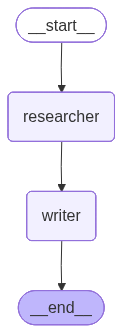

In [10]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow

In [11]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})

In [12]:
response['messages'][-1].content


"<think>\nOkay, let's tackle this query about agentic AI use cases in business. The user wants a clear summary of the findings from the search results provided.\n\nFirst, I need to parse the search results. There are five snippets from 2023 discussing different business applications. The first one mentions customer service with personalized assistance and chatbots. The second talks about supply chain optimization using predictive analytics and autonomous systems. The third is about financial services for fraud detection and robo-advisory. The fourth example is healthcare in diagnostics and drug discovery. The fifth is manufacturing for predictive maintenance and quality control.\n\nI should categorize these use cases by industry and highlight the key benefits like efficiency, personalization, and cost reduction. Also, note the technologies involved, such as predictive analytics, machine learning, and autonomous systems. Make sure to mention real-world examples like banks using agentic 

In [13]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Reasearch about the usecase of agentic ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (e11swmst7)
 Call ID: e11swmst7
  Args:
    query: agentic AI business use cases 2023 real-world examples
================================== Ai Message ==================================

<think>
Okay, let's tackle this query about agentic AI use cases in business. The user wants a clear summary of the findings from the search results provided.

First, I need to parse the search results. There are five snippets from 2023 discussing different business applications. The first one mentions customer service with personalized assistance and chatbots. The second talks about supply chain optimization using predictive analytics and autonomous systems. The third is about financial services for fraud detection and robo-advisory. The fourth example is healthc

### supervise Multi Ai Agent Architecture

In [14]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [15]:
# ===================================
# State Definition
# ===================================

# ===================================
# State Definition
# ===================================

class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""


# class SupervisorState(MessagesState):
#     """State for the supervisor multi-agent system"""
#     current_agent: str = ""
#     task_assignments: Dict[str, List[str]] = {} # track what each agent should do 
#     agent_outputs: Dict[str, Any] = {} #Store outputs from each agent
#     workflow_stage: str = "initial" #track workflow progress
#     iteration_count: int = 0
#     max_iterations:int =10
#     final_output:str=""


In [16]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [17]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [18]:
# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [19]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [20]:
# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [21]:
# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

In [22]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()

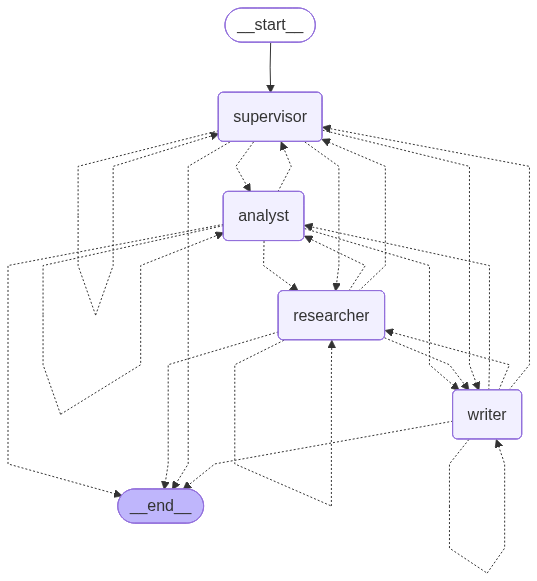

In [23]:
graph

In [24]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

for msg in response["messages"]:
    msg.pretty_print()

<think>
okay, let's see. the user said "no task." so there's no specific task given here. the current state shows that there's no research data, analysis, or report. the agents are researcher, analyst, and writer.

since there's no task, the team probably doesn't need to do anything. the supervisor should check if there's any pending work. but the current state is all false, meaning nothing has been done. if there's no task assigned, then the agents don't have anything to work on. the user might just be testing or there's a mistake. in this case, since there's no task, the correct response should be 'done' because there's nothing for the agents to process. the supervisor doesn't need to assign any agent here. so the answer is done.
</think>

done
================================== Ai Message ==================================

✅ Supervisor: All tasks complete! Great work team.


In [25]:
response = graph.invoke({
    "messages": [
        HumanMessage(
            content="What are the benefits and risks of AI in healthcare?"
        )
    ]
})
for msg in response["messages"]:
    msg.pretty_print()

<think>
okay, the user is asking about the benefits and risks of ai in healthcare. let me break down what i need to do here.

first, the current state shows that there's no research data, analysis, or report yet. so the first step is to gather information. the researcher agent should be the one to start this process. they can look up recent studies, articles, and data on ai applications in healthcare. once the researcher has collected the necessary data, the analyst can step in to evaluate the information, maybe looking at different case studies or statistical data to highlight key benefits and risks. after that, the writer can synthesize all this into a coherent report. but since the first step is gathering the data, the researcher needs to go first. i should make sure that the researcher is directed to focus on credible sources and cover both positive and negative aspects as per the question.
</think>

researcher
<think>
okay, let's see. the user provided a query about the benefits a

In [26]:
response = graph.invoke({
    "messages": [
        HumanMessage(
            content="""
Research and analyze the benefits and risks of AI in healthcare.
Create a structured report with:
1. Key benefits
2. Major risks
3. Real-world examples
4. Future outlook
"""
        )
    ]
})

for msg in response["messages"]:
    msg.pretty_print()

<think>
okay, the user wants me to figure out which agent to assign first for their task on ai in healthcare. the task is to research and analyze the benefits and risks, then create a structured report. let me break down the current state: they don't have research data, analysis, or a report yet.

first, the process probably starts with gathering information. the researcher agent is responsible for collecting data and information. since there's no research data available yet, the next logical step is to have the researcher gather the necessary data on ai's benefits and risks in healthcare. without the research data, the analyst can't perform the analysis, and the writer can't start the report. so the researcher should be the first agent to work on this. once they have the data, then the analyst can step in to analyze it, and finally the writer will create the structured report based on that analysis. so the answer here should be the researcher.
</think>

researcher
<think>
okay, let's 

In [27]:
response = graph.invoke({
    "messages": [
        HumanMessage(
            content="""
You are a multi-agent research team.

Task:
Produce a comprehensive report on AI in healthcare.

Research requirements:
- Diagnostic AI
- Drug discovery
- Personalized medicine
- Hospital automation

Analysis requirements:
- Benefits
- Risks
- Ethical concerns
- Regulatory challenges

Final output:
A professional structured report.
"""
        )
    ]
})

<think>
okay, let's start by looking at the task. the user wants a comprehensive report on ai in healthcare, covering four research areas: diagnostic ai, drug discovery, personalized medicine, and hospital automation. the analysis needs to include benefits, risks, ethical concerns, and regulatory challenges.

the current state shows that there's no research data, analysis, or report yet. since the process starts with gathering information, the first step should be the researcher. the researcher will collect data on each of the specified areas. without the initial research, the analyst can't start breaking down the information, and the writer can't produce the report. so the logical next agent is the researcher.
</think>

researcher
<think>
okay, let's see. the user is part of a multi-agent team working on a report about ai in healthcare. the current state is that they have research data but haven't done the analysis or written the report yet.

the researcher has already started gatheri